# Deliverable 5 + 6: Proposed Improvement/Task 2
## Object Detection in Overhead Remote Sensing Imagery

## 1. Project Scope

The aim of our project is to use overhead remote sensing imagery, such as images that are taken by satellites, drones etc., to identify small objects properly.

VisDrone2019 is the dataset we opted to work with. The primary reason for doing so is that as detailed in the SOA survey, data in VisDrone2019 is closely aligned with what we plan on. It includes UAV imagery with diverse types of images, such as tiny objects, a lot of people within a single frame as well as complex backgrounds.

The path through which we aim to follow is to begin with a YOLO-based baseline model and then implement improvements for better detection of small objects. Hence, we selected plain YOLOv8m as our baseline model, which would also function as a solid reproducible foundation for incorporating refinements in the future.

## 2. Importing Libraries

In [2]:
import os
import shutil
import yaml
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from ultralytics import YOLO
import pandas as pd

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics.models.yolo.detect import DetectionTrainer
from matplotlib.patches import Patch

## 3. Defining Dataset Paths

In [3]:
BASE_INPUT = "/kaggle/input/datasets/abd915/dataset-dl-proj-spring26/Datasets"

train_images_path = os.path.join(BASE_INPUT, "VisDrone2019-DET-train/images")
train_annotations_path = os.path.join(BASE_INPUT, "VisDrone2019-DET-train/annotations")

validation_images_path = os.path.join(BASE_INPUT, "VisDrone2019-DET-val/images")
validation_annotations_path = os.path.join(BASE_INPUT, "VisDrone2019-DET-val/annotations")

project_path = "/kaggle/working/Deliverable3_Baseline"
os.makedirs(project_path, exist_ok=True)

common_epochs = 20
common_seed = 42
common_image_size = 640
common_batch_size = 8

training_device = 0 if torch.cuda.is_available() else "cpu"
infer_device = training_device

device = training_device

random.seed(common_seed)
np.random.seed(common_seed)
torch.manual_seed(common_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(common_seed)

print("Common epochs:", common_epochs)
print("Common seed:", common_seed)
print("Training device:", training_device)

Common epochs: 20
Common seed: 42
Training device: 0


In [4]:
print("Training images path:", train_images_path)
print("Training annotations path:", train_annotations_path)
print()
print("Validation images path:", validation_images_path)
print("Validation annotations path:", validation_annotations_path)
print()
print("Project path:", project_path)

Training images path: /kaggle/input/datasets/abd915/dataset-dl-proj-spring26/Datasets/VisDrone2019-DET-train/images
Training annotations path: /kaggle/input/datasets/abd915/dataset-dl-proj-spring26/Datasets/VisDrone2019-DET-train/annotations

Validation images path: /kaggle/input/datasets/abd915/dataset-dl-proj-spring26/Datasets/VisDrone2019-DET-val/images
Validation annotations path: /kaggle/input/datasets/abd915/dataset-dl-proj-spring26/Datasets/VisDrone2019-DET-val/annotations

Project path: /kaggle/working/Deliverable3_Baseline


## 4. Defining the Classes

In [5]:
class_names = ["pedestrian", "people", "bicycle", "car", "van", "truck", "tricycle", "awning-tricycle", "bus", "motor"]

print("Number of classes:", len(class_names))
print()

print("Class names:")
for i in range(len(class_names)):
    print(i + 1, "-", class_names[i])

Number of classes: 10

Class names:
1 - pedestrian
2 - people
3 - bicycle
4 - car
5 - van
6 - truck
7 - tricycle
8 - awning-tricycle
9 - bus
10 - motor


## 5. Observing the Training and Validation Split

In [6]:
train_image_names = os.listdir(train_images_path)
validation_image_names = os.listdir(validation_images_path)

print("Number of training images:", len(train_image_names))
print("Number of validation images:", len(validation_image_names))

Number of training images: 6471
Number of validation images: 548


## 6. Viewing Sample Images

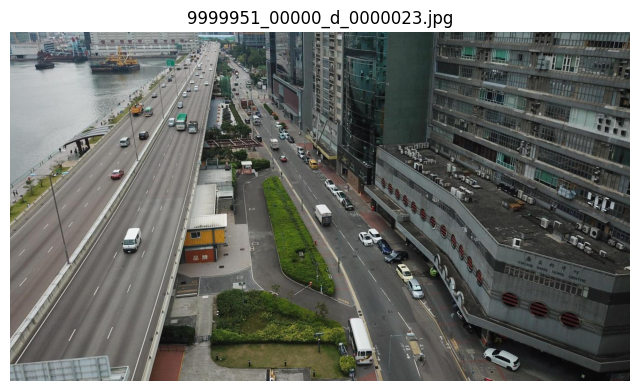

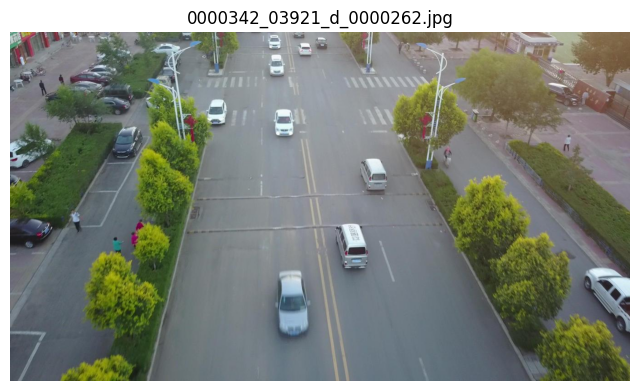

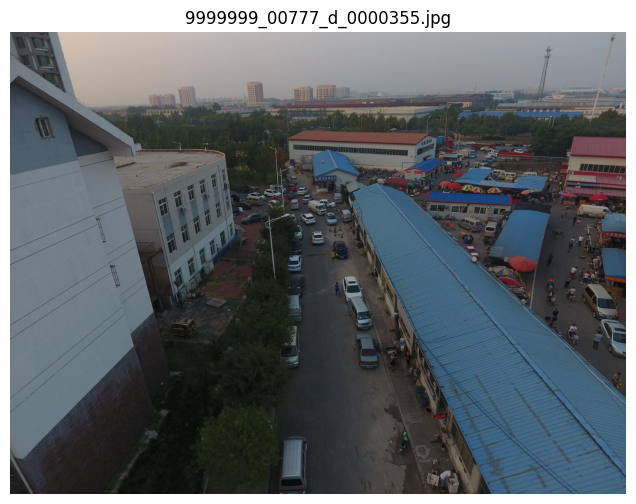

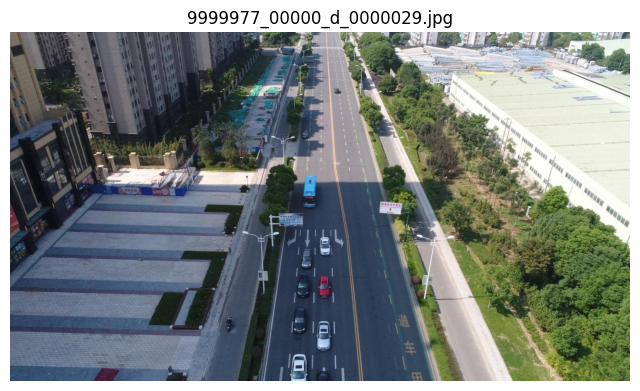

In [7]:
sample_count = 4
shown_count = 0

for i in range(len(train_image_names)):
    if shown_count == sample_count:
        break

    image_name = train_image_names[i]
    image_path = os.path.join(train_images_path, image_name)
    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize = (8, 6))
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

    shown_count += 1

## 7. Understanding the Annotations

The labels that provide us with information about the object in the image, including the object itself as well as its location, are called annotations.
The annotations that our dataset uses contain the following features: exact coordinates of the object, exact dimensions, category information along with visibility information.
Understanding them is quite crucial since they play a vital role in the training of the model.

Format:
x - x-coordinate of the bounding box,
y - y-coordinate of the bounding box,
width - width of the box,
height - height of the box,
use flag: it indicates whether the annotation should be used or not,
category - object class,
truncation - whether part of the object is cut off,
occlusion - whether part of the object is blocked

### Information Regarding Values of Each Feature

#### x

- Larger values of x indicate that the point is more towards the right side of the image and vice versa.

#### y

- Larger values of y indicate that the point is more towards the bottom side of the image and vice versa.

#### width

- Larger values of width make the box more horizontal and vice versa.

#### height

- Larger values of height make the box more horizontal and vice versa.

#### use flag

- This feature can take either of the values of 0 & 1.
- 0 represents that the annotation is ignored.
- 1 represents that the annotation is used.

#### category

- This feature can take either of the values of 0-11.
- 0 represents no class. This is usually when use flag is 0, meaning that the annotation is ignored.
- 1-10 represent each class (see the corresponding class names in number of classes section).
- 11 represents other class. This is when the object does not belong to the classes 1-10.

#### truncation

- This feature can take either of the values of 0 & 1.
- 0 represents that the object is not cut off.
- 1 represents that a part of the object is cut off.

#### occulation

- This feature can take either of the values of 0, 1 & 2.
- 0 represents that the object is completely visible.
- 1 represents that the object is partially visible, partially hidden.
- 2 represents that the object is hidden to a great extent.

In [8]:
annotation_names = sorted(os.listdir(train_annotations_path))

first_annotation_name = ""
if len(annotation_names) > 0:
    first_annotation_name = annotation_names[0]

annotation_path = os.path.join(train_annotations_path, first_annotation_name)

print("Annotation file name:", first_annotation_name)
print()
print("x,y,width,height,use flag,category,truncation,occlusion")
print()

with open(annotation_path, "r") as file:
    annotation_lines = file.readlines()

line_limit = 10
printed_count = 0

for i in range(len(annotation_lines)):
    if printed_count == line_limit:
        break

    print(annotation_lines[i].strip())
    printed_count += 1

Annotation file name: 0000002_00005_d_0000014.txt

x,y,width,height,use flag,category,truncation,occlusion

684,8,273,116,0,0,0,0
406,119,265,70,0,0,0,0
255,22,119,128,0,0,0,0
1,3,209,78,0,0,0,0
708,471,74,33,1,4,0,1
639,425,61,46,1,4,0,0
594,399,64,51,1,4,0,0
562,390,61,38,1,4,0,0
540,372,65,33,1,4,0,1
514,333,68,35,1,4,0,0


## 8. Displaying Images with Bounding Boxes

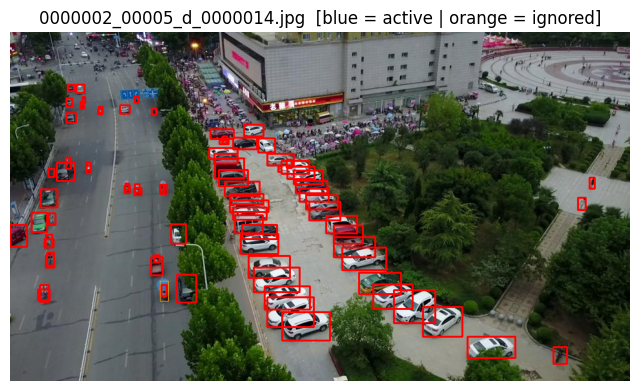

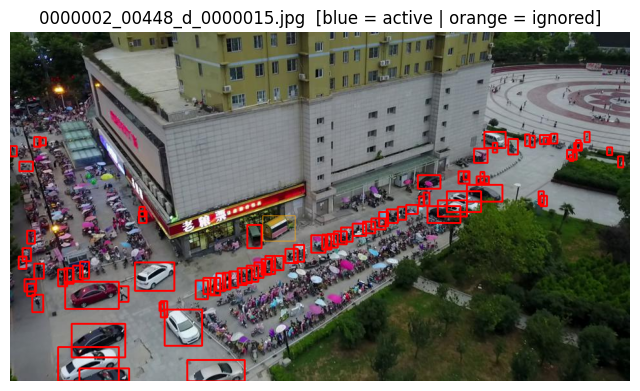

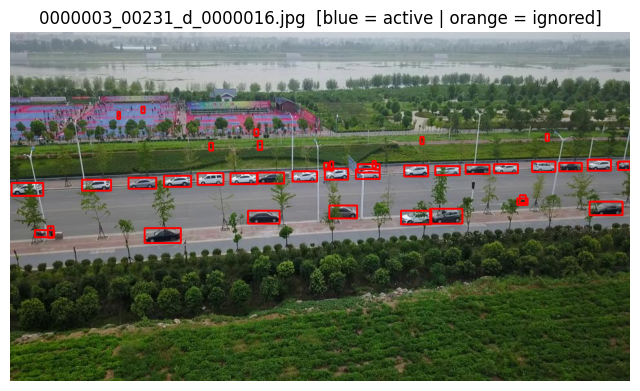

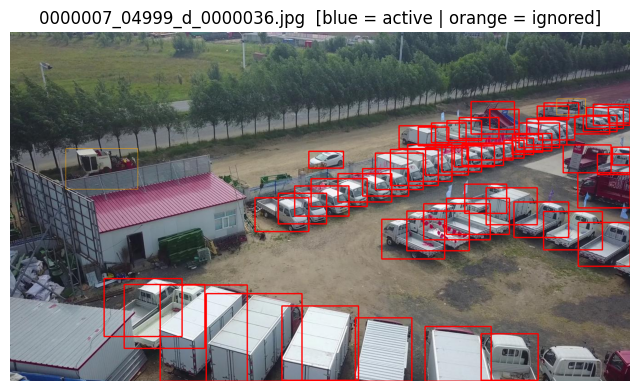

In [9]:
annotation_names = sorted(os.listdir(train_annotations_path))
shown_count = 0
image_limit = 4

for i in range(len(annotation_names)):
    if shown_count == image_limit:
        break

    annotation_name = annotation_names[i]
    annotation_path = os.path.join(train_annotations_path, annotation_name)

    image_name = annotation_name.replace(".txt", ".jpg")
    image_path = os.path.join(train_images_path, image_name)

    image = cv2.imread(image_path)
    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with open(annotation_path, "r") as file:
        annotation_lines = file.readlines()

    for j in range(len(annotation_lines)):
        line = annotation_lines[j].strip()

        if line == "":
            continue

        values = line.split(",")

        x = int(values[0])
        y = int(values[1])
        width = int(values[2])
        height = int(values[3])
        use_flag = int(values[4])
        category = int(values[5])

        if category == 0:
            continue

        start_point = (x, y)
        end_point = (x + width, y + height)

        if use_flag == 0:
            color, thickness = (255, 165, 0), 1
        else:
            color, thickness = (255, 0, 0), 2

        cv2.rectangle(image, start_point, end_point, color, thickness)

    plt.figure(figsize = (8, 6))
    plt.imshow(image)
    plt.title(image_name + "  [blue = active | orange = ignored]")
    plt.axis("off")
    plt.show()
    shown_count += 1

## 9. Preparing the Dataset for YOLO

One small problem with choosing a YOLO baseline model is that it expects annotations in a very specfic manner, which is a bit different from the way the VisDrone2019 dataset has them. The format required for YOLO is as follows:

`class_id x_center y_center width height`

Moreover, it also normalizes these dimesnions by dividing them by the image's respective dimension to obtain a value between 0 and 1.

## 10. Creating Output Folders

In [10]:
dataset_path = os.path.join(project_path, "visdrone_yolo_dataset")

train_images_output_path = os.path.join(dataset_path, "images", "train")
validation_images_output_path = os.path.join(dataset_path, "images", "val")
train_labels_output_path = os.path.join(dataset_path, "labels", "train")
validation_labels_output_path = os.path.join(dataset_path, "labels", "val")

os.makedirs(train_images_output_path, exist_ok = True)
os.makedirs(validation_images_output_path, exist_ok = True)
os.makedirs(train_labels_output_path, exist_ok = True)
os.makedirs(validation_labels_output_path, exist_ok = True)

## 11. Creating the Annotation Conversion Function

In [11]:
def convert_visdrone_annotation_to_yolo(annotation_file_path, image_file_path, label_output_file_path):

    image = Image.open(image_file_path)
    image_width, image_height = image.size

    with open(annotation_file_path, "r") as file:
        annotation_lines = file.readlines()

    yolo_lines = []
    ignored_lines = []

    for i in range(len(annotation_lines)):
        line = annotation_lines[i].strip()
        if line == "":
            continue

        values = line.split(",")
        x = int(values[0]); y = int(values[1])
        width = int(values[2]); height = int(values[3])
        use_flag = int(values[4]); category = int(values[5])

        x_center = (x + width / 2) / image_width
        y_center = (y + height / 2) / image_height
        norm_w = width  / image_width
        norm_h = height / image_height

        if use_flag == 0:
            ignored_lines.append(f"{x_center} {y_center} {norm_w} {norm_h}")
            continue

        if category == 0:
            continue
        if category == 11:
            continue

        class_id = category - 1
        yolo_lines.append(f"{class_id} {x_center} {y_center} {norm_w} {norm_h}")

    with open(label_output_file_path, "w") as file:
        for line in yolo_lines:
            file.write(line + "\n")

    if len(ignored_lines) > 0:
        ignored_output_path = label_output_file_path.replace(".txt", "_ignored.txt")
        with open(ignored_output_path, "w") as file:
            for line in ignored_lines:
                file.write(line + "\n")

## 12. Preparing the Training Data

In [12]:
train_image_names = sorted(os.listdir(train_images_path))

for i in range(len(train_image_names)):
    image_name = train_image_names[i]

    source_image_path = os.path.join(train_images_path, image_name)
    target_image_path = os.path.join(train_images_output_path, image_name)

    shutil.copy(source_image_path, target_image_path)

    annotation_name = image_name.replace(".jpg", ".txt")
    source_annotation_path = os.path.join(train_annotations_path, annotation_name)
    target_label_path = os.path.join(train_labels_output_path, annotation_name)

    if os.path.exists(source_annotation_path):
        convert_visdrone_annotation_to_yolo(source_annotation_path, source_image_path, target_label_path)

## 13. Preparing the Validation Data

In [13]:
validation_image_names = sorted(os.listdir(validation_images_path))

for i in range(len(validation_image_names)):
    image_name = validation_image_names[i]

    source_image_path = os.path.join(validation_images_path, image_name)
    target_image_path = os.path.join(validation_images_output_path, image_name)

    shutil.copy(source_image_path, target_image_path)

    annotation_name = image_name.replace(".jpg", ".txt")
    source_annotation_path = os.path.join(validation_annotations_path, annotation_name)
    target_label_path = os.path.join(validation_labels_output_path, annotation_name)

    if os.path.exists(source_annotation_path):
        convert_visdrone_annotation_to_yolo(source_annotation_path, source_image_path, target_label_path)

## 14. Confirming the Prepared Data

In [14]:
prepared_train_images = os.listdir(train_images_output_path)
prepared_train_labels = os.listdir(train_labels_output_path)

prepared_validation_images = os.listdir(validation_images_output_path)
prepared_validation_labels = os.listdir(validation_labels_output_path)

print("Prepared training images:", len(prepared_train_images))
print("Prepared training labels:", len(prepared_train_labels))
print()
print("Prepared validation images:", len(prepared_validation_images))
print("Prepared validation labels:", len(prepared_validation_labels))

Prepared training images: 6471
Prepared training labels: 9491

Prepared validation images: 548
Prepared validation labels: 899


## 15. Creating the YAML File

In [15]:
yaml_file_path = os.path.join(project_path, "visdrone_dataset.yaml")

yaml_data = {"path": dataset_path, "train": "images/train", "val": "images/val", "nc": len(class_names), "names": class_names}

with open(yaml_file_path, "w") as file:
    yaml.dump(yaml_data, file, sort_keys = False)

print("YAML file path:", yaml_file_path)

YAML file path: /kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml


In [16]:
with open(yaml_file_path, "r") as file:
    yaml_content = file.read()

print(yaml_content)

path: /kaggle/working/Deliverable3_Baseline/visdrone_yolo_dataset
train: images/train
val: images/val
nc: 10
names:
- pedestrian
- people
- bicycle
- car
- van
- truck
- tricycle
- awning-tricycle
- bus
- motor



## 16. Loading the Baseline Model

In [17]:
model = YOLO("yolov8m.pt")

print("Model information:")
layers, parameter_count, gradients, gflops = model.info()

print("Layers:", layers)
print("Parameter Count:", parameter_count)
print("GFLOPs:", gflops)

Model information:
YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs
Layers: 169
Parameter Count: 25902640
GFLOPs: 79.3204224


## 17. Training the Baseline Model

In [18]:
training_results = model.train(data = yaml_file_path, epochs = common_epochs, imgsz = common_image_size, device = training_device, batch = common_batch_size, project = project_path,
    name = "yolov8m_visdrone_baseline", pretrained = True, seed = common_seed, exist_ok = True)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_visdrone_baseline, nbs=64, nms=False, opset=None, optimize=False, opt

## 18. Evaluating the Baseline Model

In [19]:
validation_results = model.val(data = yaml_file_path, split = "val", device = training_device)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2060.6±853.1 MB/s, size: 150.7 KB)
val: Scanning /kaggle/working/Deliverable3_Baseline/visdrone_yolo_dataset/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 191.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.5it/s 13.8s
                   all        548      38759      0.521      0.414      0.406       0.24
            pedestrian        520       8844      0.567      0.436      0.437      0.197
                people        482       5125      0.579       0.32      0.334      0.127
               bicycle        364       1287      0.232      0.223      0.149     0.0668
                   car        515      14064      0.705      0.804      0.793       0.55
   

In [20]:
print("Precision:", validation_results.box.mp)
print("Recall:", validation_results.box.mr)
print("mAP@0.5:", validation_results.box.map50)
print("mAP@0.5:0.95:", validation_results.box.map)

Precision: 0.5210906554837522
Recall: 0.41439662653397963
mAP@0.5: 0.40579530729292507
mAP@0.5:0.95: 0.24043588417669506


## 19. Sample Predictions vs Ground Truth

In [21]:
def draw_ground_truth_boxes(image_path, annotation_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with open(annotation_path, "r") as file:
        annotation_lines = file.readlines()

    for i in range(len(annotation_lines)):
        line = annotation_lines[i].strip()

        if line == "":
            continue

        values = line.split(",")

        x = int(values[0])
        y = int(values[1])
        width = int(values[2])
        height = int(values[3])
        use_flag = int(values[4])
        category = int(values[5])

        if category == 0:
            continue

        start_point = (x, y)
        end_point = (x + width, y + height)

        if use_flag == 0:
            cv2.rectangle(image, start_point, end_point, (255, 165, 0), 1)
        else:
            cv2.rectangle(image, start_point, end_point, (0, 255, 0), 2)
        
    return image

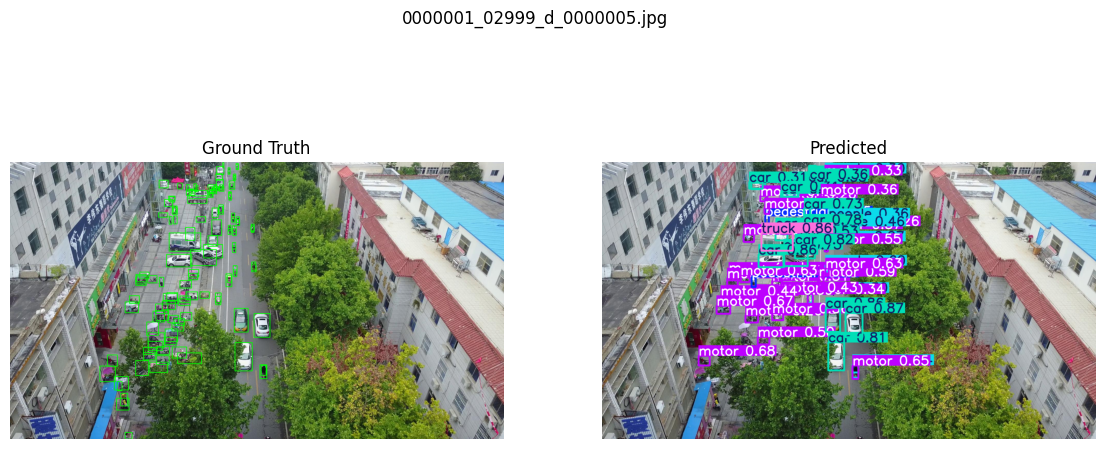

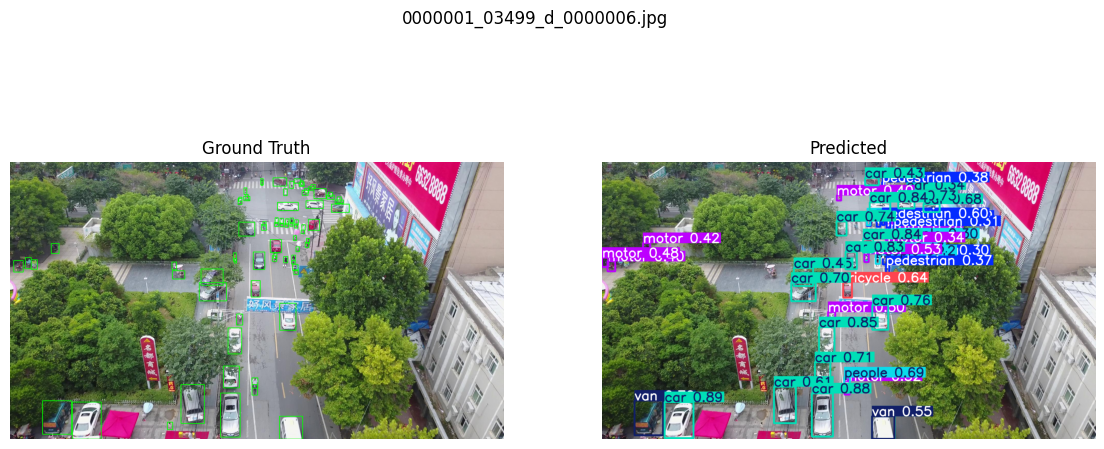

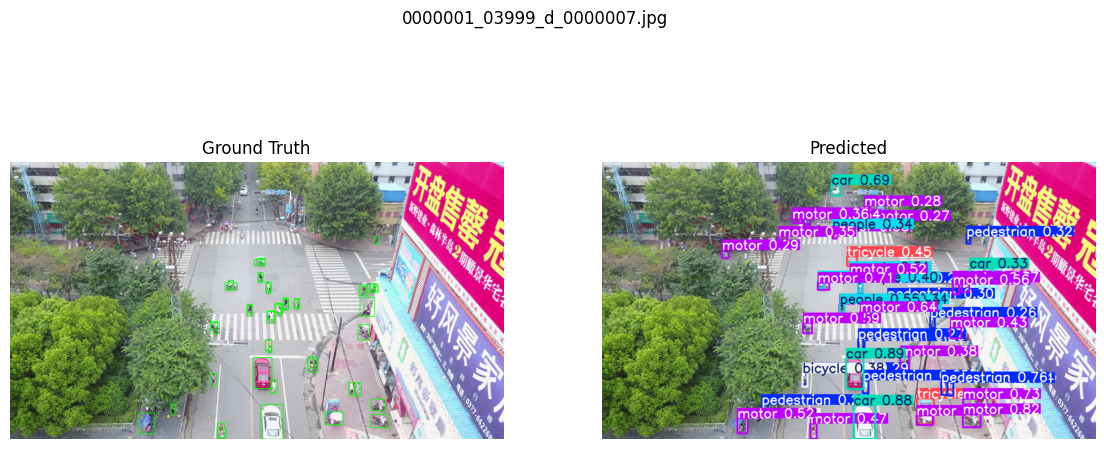

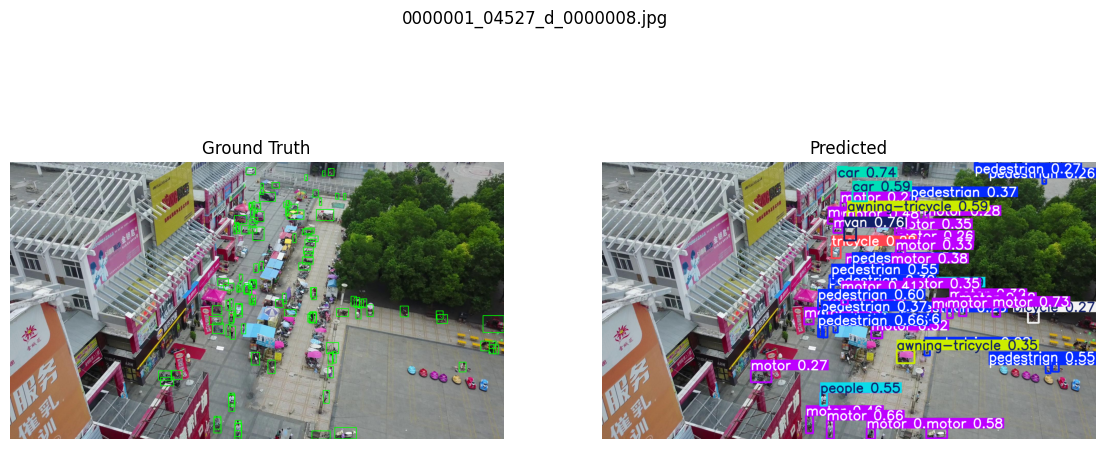

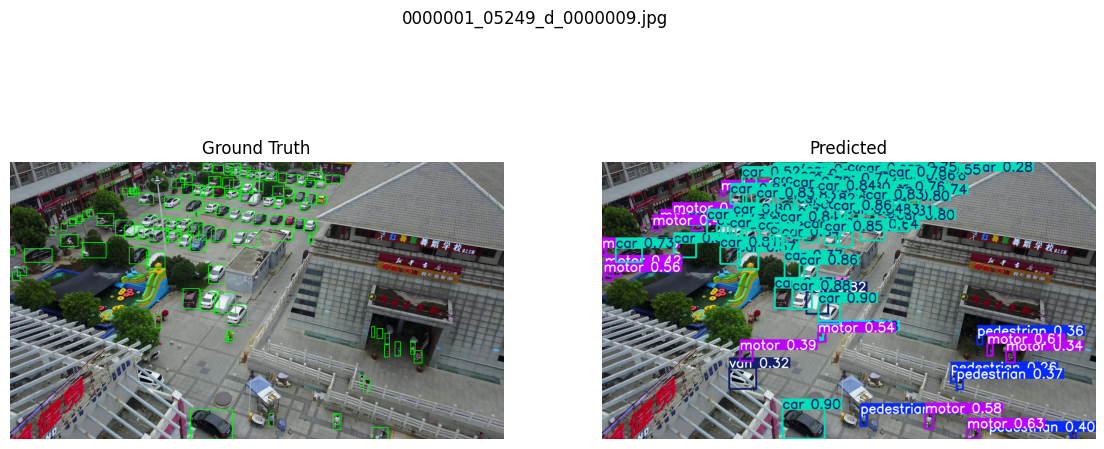

FPS measured on validation images: 48.773993553539476


In [22]:
sample_image_names = sorted(os.listdir(validation_images_output_path))
sample_limit = 5
shown_count = 0

infer_device = 0 if torch.cuda.is_available() else "cpu"

best_weights = os.path.join(project_path, "yolov8m_visdrone_baseline", "weights", "best.pt")
infer_model = YOLO(best_weights)

for i in range(len(sample_image_names)):
    if shown_count == sample_limit:
        break

    image_name = sample_image_names[i]

    image_path = os.path.join(validation_images_output_path, image_name)
    annotation_name = image_name.replace(".jpg", ".txt")
    annotation_path = os.path.join(validation_annotations_path, annotation_name)

    ground_truth_image = draw_ground_truth_boxes(image_path, annotation_path)

    prediction_results = infer_model.predict(source = image_path, save = False, verbose = False, device = infer_device)

    predicted_image = prediction_results[0].plot()
    predicted_image = cv2.cvtColor(predicted_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize = (14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(ground_truth_image)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_image)
    plt.title("Predicted")
    plt.axis("off")

    plt.suptitle(image_name)
    plt.show()

    shown_count += 1

fps_image_names = sorted(os.listdir(validation_images_output_path))
fps_image_paths = []

for i in range(len(fps_image_names)):
    image_name = fps_image_names[i]
    image_path = os.path.join(validation_images_output_path, image_name)
    fps_image_paths.append(image_path)
    
if len(fps_image_paths) > 0:
    infer_model.predict(source = fps_image_paths[0], save = False, verbose = False, device = infer_device)

start_time = time.time()

for i in range(len(fps_image_paths)):
    infer_model.predict(source = fps_image_paths[i], save = False, verbose = False,device = infer_device)

end_time = time.time()

total_time = end_time - start_time
fps = len(fps_image_paths) / total_time

print("FPS measured on validation images:", fps)

baseline_results = {"validation_results": validation_results, "fps": fps, "parameter_count": parameter_count, "gflops": gflops}

## 20. Phase 4 Variant

This part is included as the direct extension of the phase 3 notebook. The baseline part above remains unchanged.
Here, a new version called “baseline + masking” is added. The validation dataset remains as it is. Only training process is modified using background masking.

## 21. Creating a New Folder for Phase 4

In [23]:
phase4_path = os.path.join(project_path, "Deliverable4_Variants")
os.makedirs(phase4_path, exist_ok = True)

print("Phase 4 path:", phase4_path)

Phase 4 path: /kaggle/working/Deliverable3_Baseline/Deliverable4_Variants


## 22. Defining Training-Time Background Masking

In [24]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def boxes_overlap(first_box, second_box):
    if first_box[2] <= second_box[0] or second_box[2] <= first_box[0]:
        return False
    if first_box[3] <= second_box[1] or second_box[3] <= first_box[1]:
        return False
    return True

def expand_box(box, image_width, image_height, margin_ratio = 0.02):
    x1, y1, x2, y2 = box
    margin_x = int(image_width * margin_ratio)
    margin_y = int(image_height * margin_ratio)

    x1 = max(0, x1 - margin_x)
    y1 = max(0, y1 - margin_y)
    x2 = min(image_width, x2 + margin_x)
    y2 = min(image_height, y2 + margin_y)

    return (x1, y1, x2, y2)

In [25]:
def apply_background_mask_to_batch(batch, min_patch_count = 4, max_patch_count = 8, min_patch_ratio = 0.03, max_patch_ratio = 0.10, max_try_count = 20, masking_probability = 0.50, protect_margin_ratio = 0.02, fill_mode = "mean"):
    if "img" not in batch or "bboxes" not in batch or "batch_idx" not in batch:
        return

    images = batch["img"]
    boxes = batch["bboxes"]
    batch_index = batch["batch_idx"]
    batch_size = len(images)

    im_files = batch.get("im_file", None)

    for i in range(batch_size):
        if torch.rand(1).item() > masking_probability:
            continue

        image = images[i]
        image_height = image.shape[1]
        image_width = image.shape[2]
        image_boxes = []

        for j in range(len(boxes)):
            if int(batch_index[j].item()) != i:
                continue

            x_center = boxes[j][0].item()
            y_center = boxes[j][1].item()
            box_width = boxes[j][2].item()
            box_height= boxes[j][3].item()

            x1 = int((x_center - box_width  / 2) * image_width)
            y1 = int((y_center - box_height / 2) * image_height)
            x2 = int((x_center + box_width  / 2) * image_width)
            y2 = int((y_center + box_height / 2) * image_height)

            x1 = max(0, min(x1, image_width  - 1))
            y1 = max(0, min(y1, image_height - 1))
            x2 = max(1, min(x2, image_width))
            y2 = max(1, min(y2, image_height))

            protected_box = expand_box((x1, y1, x2, y2), image_width, image_height, margin_ratio = protect_margin_ratio)
            image_boxes.append(protected_box)

        if im_files is not None and i < len(im_files):
            img_path   = im_files[i]
            label_path = img_path.replace("/images/", "/labels/").replace(".jpg", "_ignored.txt")
            if os.path.exists(label_path):
                with open(label_path, "r") as f:
                    for row in f:
                        row = row.strip()
                        if row == "":
                            continue
                        parts = row.split()
                        if len(parts) < 4:
                            continue
                        xc, yc, nw, nh = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
                        ix1 = int((xc - nw / 2) * image_width)
                        iy1 = int((yc - nh / 2) * image_height)
                        ix2 = int((xc + nw / 2) * image_width)
                        iy2 = int((yc + nh / 2) * image_height)
                        ix1 = max(0, min(ix1, image_width  - 1))
                        iy1 = max(0, min(iy1, image_height - 1))
                        ix2 = max(1, min(ix2, image_width))
                        iy2 = max(1, min(iy2, image_height))
                        protected_box = expand_box((ix1, iy1, ix2, iy2), image_width, image_height, margin_ratio = protect_margin_ratio)
                        image_boxes.append(protected_box)

        patch_count = torch.randint(min_patch_count, max_patch_count + 1, (1,)).item()

        for j in range(patch_count):
            for k in range(max_try_count):
                patch_width = int(image_width * (min_patch_ratio + (max_patch_ratio - min_patch_ratio) * torch.rand(1).item()))
                patch_height = int(image_height * (min_patch_ratio + (max_patch_ratio - min_patch_ratio) * torch.rand(1).item()))

                patch_width = max(1, min(patch_width, image_width))
                patch_height = max(1, min(patch_height, image_height))

                x1 = torch.randint(0, image_width - patch_width + 1, (1,)).item()
                y1 = torch.randint(0, image_height - patch_height + 1, (1,)).item()
                x2 = x1 + patch_width
                y2 = y1 + patch_height

                patch_box = (x1, y1, x2, y2)
                overlaps_object = False

                for m in range(len(image_boxes)):
                    if boxes_overlap(patch_box, image_boxes[m]):
                        overlaps_object = True
                        break

                if overlaps_object == False:
                    if fill_mode == "mean":
                        fill_value = image.mean(dim = (1, 2), keepdim = True)
                        image[:, y1:y2, x1:x2] = fill_value

                    elif fill_mode == "random":
                        image[:, y1:y2, x1:x2] = torch.rand_like(image[:, y1:y2, x1:x2])

                    else:
                        image[:, y1:y2, x1:x2] = 0

                    break

In [ ]:

def make_masked_trainer_class(masking_settings = None):

    if masking_settings is None:
        masking_settings = {}

    class _MaskedDetectionTrainer(DetectionTrainer):
        def preprocess_batch(self, batch):
            batch = super().preprocess_batch(batch)
            apply_background_mask_to_batch(batch, **masking_settings)
            return batch

    return _MaskedDetectionTrainer

## 23. Viewing Sample Images After Background Masking

In [27]:
def create_masked_sample_image(image_path, annotation_path, min_patch_count = 4, max_patch_count = 8, min_patch_ratio = 0.03, max_patch_ratio = 0.10, max_try_count = 20, protect_margin_ratio = 0.02, fill_mode = "mean"):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masked_image = image.copy()

    image_height = masked_image.shape[0]
    image_width = masked_image.shape[1]

    object_boxes = []

    with open(annotation_path, "r") as file:
        annotation_lines = file.readlines()

    for i in range(len(annotation_lines)):
        line = annotation_lines[i].strip()

        if line == "":
            continue

        values = line.split(",")

        x = int(values[0])
        y = int(values[1])
        width = int(values[2])
        height = int(values[3])
        use_flag = int(values[4])
        category = int(values[5])

        if category == 0:
            continue

        if category == 11 and use_flag == 1:
            continue

        x1 = x
        y1 = y
        x2 = x + width
        y2 = y + height

        protected_box = expand_box((x1, y1, x2, y2), image_width, image_height, margin_ratio = protect_margin_ratio)
        object_boxes.append(protected_box)

    patch_count = torch.randint(min_patch_count, max_patch_count + 1, (1,)).item()

    for i in range(patch_count):
        for j in range(max_try_count):
            patch_width = int(image_width * (min_patch_ratio + (max_patch_ratio - min_patch_ratio) * torch.rand(1).item()))
            patch_height = int(image_height * (min_patch_ratio + (max_patch_ratio - min_patch_ratio) * torch.rand(1).item()))

            patch_width = max(1, min(patch_width, image_width))
            patch_height = max(1, min(patch_height, image_height))

            x1 = torch.randint(0, image_width - patch_width + 1, (1,)).item()
            y1 = torch.randint(0, image_height - patch_height + 1, (1,)).item()
            x2 = x1 + patch_width
            y2 = y1 + patch_height

            patch_box = (x1, y1, x2, y2)
            overlaps_object = False

            for k in range(len(object_boxes)):
                if boxes_overlap(patch_box, object_boxes[k]):
                    overlaps_object = True
                    break

            if overlaps_object == False:
                if fill_mode == "mean":
                    mean_color = masked_image.mean(axis = (0, 1))
                    masked_image[y1:y2, x1:x2] = mean_color

                elif fill_mode == "random":
                    random_patch = torch.randint(0, 256, (patch_height, patch_width, 3), dtype = torch.uint8).numpy()
                    masked_image[y1:y2, x1:x2] = random_patch

                else:
                    masked_image[y1:y2, x1:x2] = 0

                break

    return image, masked_image

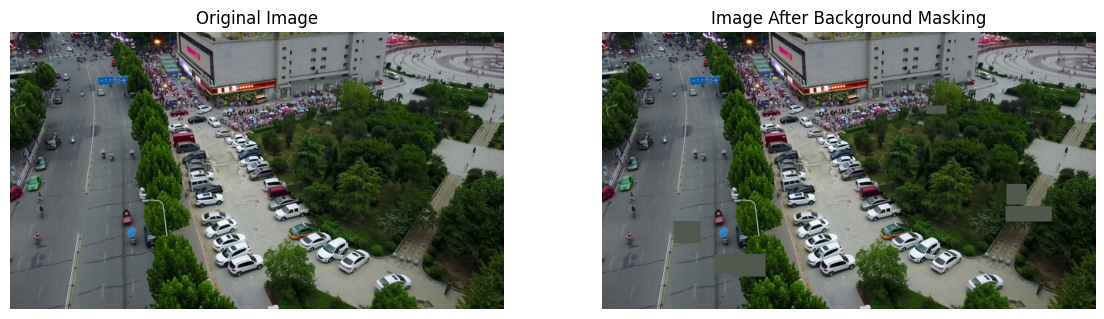

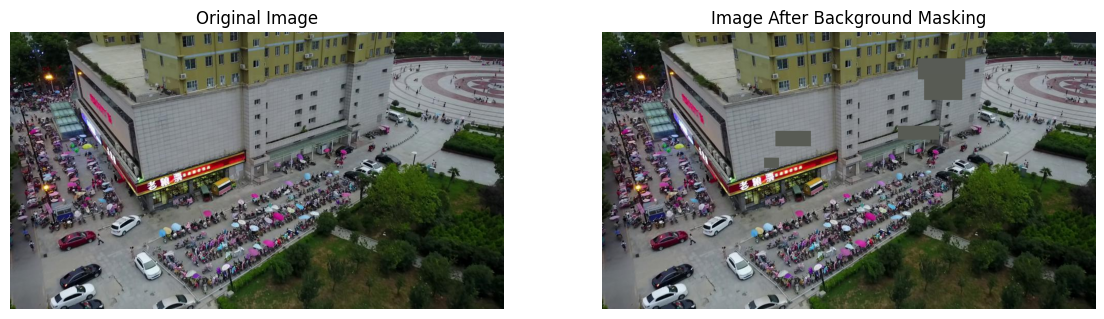

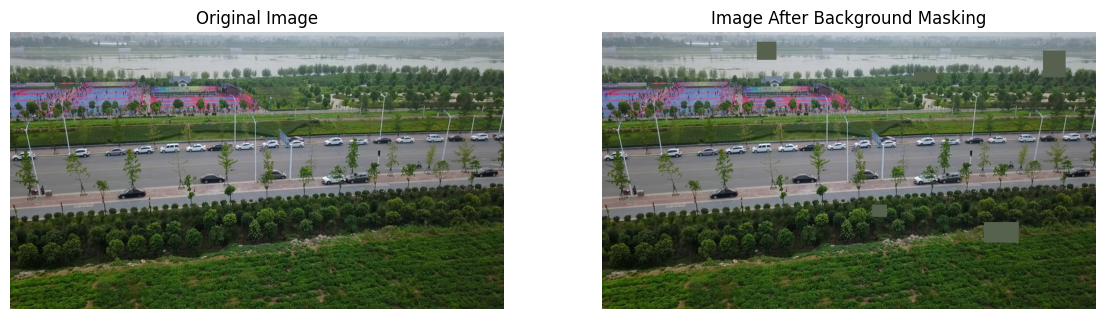

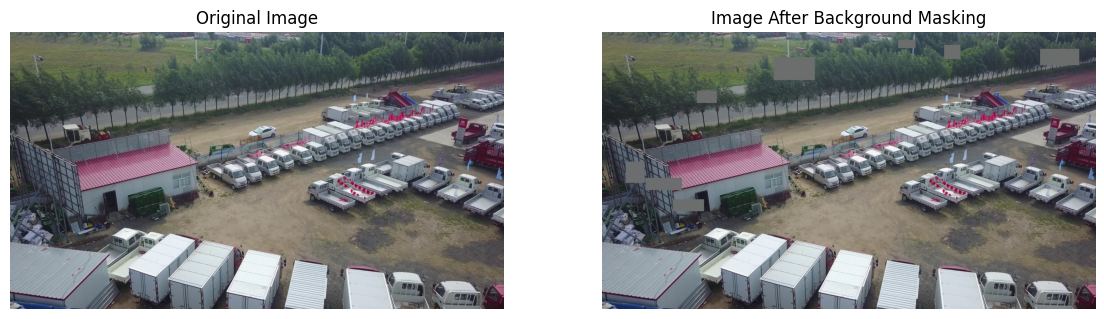

In [28]:
sample_count = 4
shown_count = 0

sample_image_names = sorted(os.listdir(train_images_path))

for i in range(len(sample_image_names)):
    if shown_count == sample_count:
        break

    image_name = sample_image_names[i]
    image_path = os.path.join(train_images_path, image_name)

    annotation_name = image_name.replace(".jpg", ".txt")
    annotation_path = os.path.join(train_annotations_path, annotation_name)

    if not os.path.exists(annotation_path):
        continue

    result = create_masked_sample_image(image_path, annotation_path)

    if result is None:
        continue

    original_image, masked_image = result

    plt.figure(figsize = (14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masked_image)
    plt.title("Image After Background Masking")
    plt.axis("off")

    plt.show()

    shown_count += 1

## 24. Using the Original YAML File for the Masking and Class-Weighting Variants

In [29]:
print("YAML file used for baseline, masking and class-weighting", yaml_file_path)

YAML file used for baseline, masking and class-weighting /kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml


## 25. Calculating Class Weights from the Training Labels

In [30]:
def calculate_class_weights(label_folder_path, number_of_classes):
    class_counts = [0] * number_of_classes

    label_file_names = sorted(os.listdir(label_folder_path))

    for i in range(len(label_file_names)):
        label_file_name = label_file_names[i]
        label_file_path = os.path.join(label_folder_path, label_file_name)

        with open(label_file_path, "r") as file:
            label_lines = file.readlines()

        for j in range(len(label_lines)):
            line = label_lines[j].strip()

            if line == "":
                continue

            values = line.split()
            class_id = int(float(values[0]))
            class_counts[class_id] += 1

    total_objects = sum(class_counts)
    class_weights = []

    for i in range(len(class_counts)):
        if class_counts[i] == 0:
            class_weight = 1.0
        else:
            class_weight = total_objects / (number_of_classes * class_counts[i])

        class_weights.append(class_weight)

    average_weight = sum(class_weights) / len(class_weights)

    for i in range(len(class_weights)):
        class_weights[i] = class_weights[i] / average_weight

    return class_counts, class_weights

In [31]:
class_counts, class_weights = calculate_class_weights(train_labels_output_path, len(class_names))

print("Class counts:")
for i in range(len(class_names)):
    print(class_names[i], ":", class_counts[i])

print()
print("Class weights:")
for i in range(len(class_names)):
    print(class_names[i], ":", round(class_weights[i], 4))

Class counts:
pedestrian : 89682
people : 27059
bicycle : 10480
car : 144867
van : 24956
truck : 12875
tricycle : 4812
awning-tricycle : 3246
bus : 5926
motor : 29647

Class weights:
pedestrian : 0.113
people : 0.3746
bicycle : 0.9672
car : 0.07
van : 0.4062
truck : 0.7873
tricycle : 2.1065
awning-tricycle : 3.1228
bus : 1.7105
motor : 0.3419


In [32]:
class_weighting_power = 0.50

print("Class-weighting will be applied using Ultralytics cls_pw.")
print("Class-weighting power:", class_weighting_power)

Class-weighting will be applied using Ultralytics cls_pw.
Class-weighting power: 0.5


## 26. Creating One Training Function and One Evaluation Function

In [33]:
def train_variant(model_source, data_source, run_name, fine_tune_epochs = 20, use_masking = False, masking_settings = None, use_class_weighting = False,
    class_weighting_power = 0.50, transfer_weights_from = None, cache_mode = False, lr0 = 1e-4):

    if model_source.endswith(".yaml"):
        model = YOLO(model_source)
        if transfer_weights_from is not None:
            model = model.load(transfer_weights_from)
            print(f"[transfer_weights] Loaded compatible weights from {transfer_weights_from}")
    else:
        model = YOLO(model_source)

    print(f"Model information for {run_name}")
    layers, parameter_count, gradients, gflops = model.info()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    train_arguments = {"data": data_source, "epochs": fine_tune_epochs, "imgsz": common_image_size, "device": training_device, "batch": common_batch_size,
        "project": phase4_path, "name": run_name, "pretrained": True, "seed": common_seed, "exist_ok": True, "cache": cache_mode,
        "mosaic": 0.0, "lr0": lr0, "lrf": 0.01, "optimizer": "AdamW",}
    
    if use_class_weighting == True:
        train_arguments["cls_pw"] = class_weighting_power
    if use_masking == True:
        masked_trainer_cls = make_masked_trainer_class(masking_settings)
        train_arguments["trainer"] = masked_trainer_cls

    training_results   = model.train(**train_arguments)
    validation_results = model.val(data = data_source, split = "val", device = training_device)

    return {"model": model, "layers": layers, "parameter_count": parameter_count, "gflops": gflops, "training_results": training_results,
        "validation_results": validation_results}

In [34]:
def measure_fps(weight_file_path, image_folder_path):
    image_names = sorted(os.listdir(image_folder_path))
    image_paths = []

    for i in range(len(image_names)):
        image_name = image_names[i]
        image_path = os.path.join(image_folder_path, image_name)
        image_paths.append(image_path)

    infer_model = YOLO(weight_file_path)
    warmup_count = min(5, len(image_paths))

    for i in range(warmup_count):
        infer_model.predict(source = image_paths[i], save = False, verbose = False, device = infer_device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    for i in range(len(image_paths)):
        infer_model.predict(source = image_paths[i], save = False, verbose = False, device = infer_device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.time()

    total_time = end_time - start_time
    fps = len(image_paths) / total_time

    return fps

## 27. Training and Evaluating Baseline + Masking

In [35]:
baseline_weight_file_path = os.path.join(project_path, "yolov8m_visdrone_baseline", "weights", "best.pt")

masking_results = train_variant(model_source = baseline_weight_file_path, data_source = yaml_file_path, run_name = "yolov8m_visdrone_masking", fine_tune_epochs = 20, use_masking = True, 
        masking_settings = {"min_patch_count": 4, "max_patch_count": 8, "min_patch_ratio": 0.03, "max_patch_ratio": 0.10, "masking_probability": 0.50,
        "protect_margin_ratio": 0.02, "fill_mode": "mean"}, lr0 = 2e-4)

masking_weight_file_path = os.path.join(phase4_path, "yolov8m_visdrone_masking", "weights", "best.pt")
masking_fps = measure_fps(masking_weight_file_path, validation_images_output_path)

print("Baseline + Masking Precision:", masking_results["validation_results"].box.mp)
print("Baseline + Masking Recall:", masking_results["validation_results"].box.mr)
print("Baseline + Masking mAP@0.5:", masking_results["validation_results"].box.map50)
print("Baseline + Masking mAP@0.5:0.95:", masking_results["validation_results"].box.map)
print("Baseline + Masking FPS:", masking_fps)

Model information for yolov8m_visdrone_masking
Model summary: 170 layers, 25,862,110 parameters, 0 gradients, 79.1 GFLOPs
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working

## 28. Training and Evaluating Baseline + Class Weighting

In [36]:
class_weighting_results = train_variant(model_source = baseline_weight_file_path, data_source = yaml_file_path, run_name = "yolov8m_visdrone_class_weighting", fine_tune_epochs = 20, 
                use_class_weighting = True, class_weighting_power = class_weighting_power, lr0 = 3e-4)

class_weighting_weight_file_path = os.path.join(phase4_path, "yolov8m_visdrone_class_weighting", "weights", "best.pt")
class_weighting_fps = measure_fps(class_weighting_weight_file_path, validation_images_output_path)

print("Baseline + Class Weighting Precision:", class_weighting_results["validation_results"].box.mp)
print("Baseline + Class Weighting Recall:", class_weighting_results["validation_results"].box.mr)
print("Baseline + Class Weighting mAP@0.5:", class_weighting_results["validation_results"].box.map50)
print("Baseline + Class Weighting mAP@0.5:0.95:", class_weighting_results["validation_results"].box.map)
print("Baseline + Class Weighting FPS:", class_weighting_fps)

Model information for yolov8m_visdrone_class_weighting
Model summary: 170 layers, 25,862,110 parameters, 0 gradients, 79.1 GFLOPs
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle

## 29. Training and Evaluating P2 Head Alone Variant

In [37]:
p2_results = train_variant(model_source = "yolov8m-p2.yaml", data_source = yaml_file_path, run_name = "yolov8m_visdrone_p2", fine_tune_epochs = 20, 
                           transfer_weights_from = baseline_weight_file_path, lr0 = 3e-4)

p2_weight_file_path = os.path.join(phase4_path, "yolov8m_visdrone_p2", "weights", "best.pt")
p2_fps = measure_fps(p2_weight_file_path, validation_images_output_path)

print("Baseline + P2 Precision:", p2_results["validation_results"].box.mp)
print("Baseline + P2 Recall:", p2_results["validation_results"].box.mr)
print("Baseline + P2 mAP@0.5:", p2_results["validation_results"].box.map50)
print("Baseline + P2 mAP@0.5:0.95:", p2_results["validation_results"].box.map)
print("Baseline + P2 FPS:", p2_fps)

Transferred 319/581 items from pretrained weights
[transfer_weights] Loaded compatible weights from /kaggle/working/Deliverable3_Baseline/yolov8m_visdrone_baseline/weights/best.pt
Model information for yolov8m_visdrone_p2
YOLOv8m-p2 summary: 209 layers, 25,082,496 parameters, 25,082,480 gradients, 99.0 GFLOPs
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

## 30. Training and Evaluating Baseline + All (P2 + Masking + CW)

In [38]:
all_results = train_variant(model_source = "yolov8m-p2.yaml", data_source = yaml_file_path, run_name = "yolov8m_visdrone_all", fine_tune_epochs = 20, use_masking = True,
    masking_settings = {"min_patch_count": 4, "max_patch_count": 8, "min_patch_ratio": 0.03, "max_patch_ratio": 0.10, "masking_probability": 0.50, "protect_margin_ratio": 0.02, 
                        "fill_mode": "mean"}, use_class_weighting = True, class_weighting_power = class_weighting_power, transfer_weights_from = baseline_weight_file_path, lr0 = 2e-4)

all_weight_file_path = os.path.join(phase4_path, "yolov8m_visdrone_all", "weights", "best.pt")
all_fps = measure_fps(all_weight_file_path, validation_images_output_path)

print("Baseline + All Precision:", all_results["validation_results"].box.mp)
print("Baseline + All Recall:", all_results["validation_results"].box.mr)
print("Baseline + All mAP@0.5:", all_results["validation_results"].box.map50)
print("Baseline + All mAP@0.5:0.95:", all_results["validation_results"].box.map)
print("Baseline + All FPS:", all_fps)

Transferred 319/581 items from pretrained weights
[transfer_weights] Loaded compatible weights from /kaggle/working/Deliverable3_Baseline/yolov8m_visdrone_baseline/weights/best.pt
Model information for yolov8m_visdrone_all
YOLOv8m-p2 summary: 209 layers, 25,082,496 parameters, 25,082,480 gradients, 99.0 GFLOPs
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deliverable3_Baseline/visdrone_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01

## 31. Recording the Result Summary for All Versions

In [39]:
summary_rows = []

summary_rows.append({"Model": "Baseline", "Precision": baseline_results["validation_results"].box.mp, "Recall": baseline_results["validation_results"].box.mr,
    "mAP@0.5": baseline_results["validation_results"].box.map50, "mAP@0.5:0.95": baseline_results["validation_results"].box.map, "FPS": baseline_results["fps"],
    "Params": baseline_results["parameter_count"], "GFLOPs": baseline_results["gflops"]})

summary_rows.append({"Model": "Baseline + Masking", "Precision": masking_results["validation_results"].box.mp, "Recall": masking_results["validation_results"].box.mr,
    "mAP@0.5": masking_results["validation_results"].box.map50, "mAP@0.5:0.95": masking_results["validation_results"].box.map, "FPS": masking_fps,
    "Params": masking_results["parameter_count"], "GFLOPs": masking_results["gflops"]})

summary_rows.append({"Model": "Baseline + Class Weighting", "Precision": class_weighting_results["validation_results"].box.mp, "Recall": class_weighting_results["validation_results"].box.mr,
    "mAP@0.5": class_weighting_results["validation_results"].box.map50, "mAP@0.5:0.95": class_weighting_results["validation_results"].box.map, "FPS": class_weighting_fps,
    "Params": class_weighting_results["parameter_count"], "GFLOPs": class_weighting_results["gflops"]})

summary_rows.append({"Model": "Baseline + P2", "Precision": p2_results["validation_results"].box.mp, "Recall": p2_results["validation_results"].box.mr,
    "mAP@0.5": p2_results["validation_results"].box.map50, "mAP@0.5:0.95": p2_results["validation_results"].box.map, "FPS": p2_fps,
    "Params": p2_results["parameter_count"], "GFLOPs": p2_results["gflops"]})

summary_rows.append({"Model": "Baseline + All", "Precision": all_results["validation_results"].box.mp, "Recall": all_results["validation_results"].box.mr,
    "mAP@0.5": all_results["validation_results"].box.map50, "mAP@0.5:0.95": all_results["validation_results"].box.map, "FPS": all_fps,
    "Params": all_results["parameter_count"], "GFLOPs": all_results["gflops"]})

summary_table = pd.DataFrame(summary_rows)
summary_table

,Model,Precision,Recall,mAP@0.5,mAP@0.5:0.95,FPS,Params,GFLOPs
0,Baseline,0.521091,0.414397,0.405795,0.240436,48.773994,25902640,79.320422
1,Baseline + Masking,0.542763,0.419420,0.414468,0.245382,49.029640,25862110,79.094630
2,Baseline + Class Weighting,0.538737,0.424564,0.414188,0.246215,48.882231,25862110,79.094630
3,Baseline + P2,0.551006,0.403039,0.403817,0.239920,39.927060,25082496,98.997402
4,Baseline + All,0.544565,0.402091,0.397292,0.235070,39.834678,25082496,98.997402


PER-CLASS mAP@0.5:0.95  —  the explainability source for every variant claim
                 Baseline  + Masking    + CW    + P2   + All  + Masking Δ  + CW Δ  + P2 Δ  + All Δ
pedestrian         0.1971     0.2057  0.2038  0.2049  0.1986       0.0086  0.0067  0.0078   0.0015
people             0.1266     0.1286  0.1285  0.1374  0.1303       0.0020  0.0019  0.0108   0.0037
bicycle            0.0668     0.0721  0.0728  0.0634  0.0649       0.0053  0.0060 -0.0034  -0.0019
car                0.5501     0.5545  0.5550  0.5560  0.5473       0.0045  0.0050  0.0059  -0.0028
van                0.3131     0.3240  0.3226  0.3131  0.3087       0.0109  0.0095 -0.0000  -0.0044
truck              0.2688     0.2722  0.2701  0.2670  0.2566       0.0034  0.0013 -0.0018  -0.0122
tricycle           0.1730     0.1775  0.1848  0.1616  0.1625       0.0045  0.0118 -0.0115  -0.0105
awning-tricycle    0.0974     0.0923  0.0978  0.0973  0.0888      -0.0050  0.0005 -0.0001  -0.0086
bus                0.4095     0.

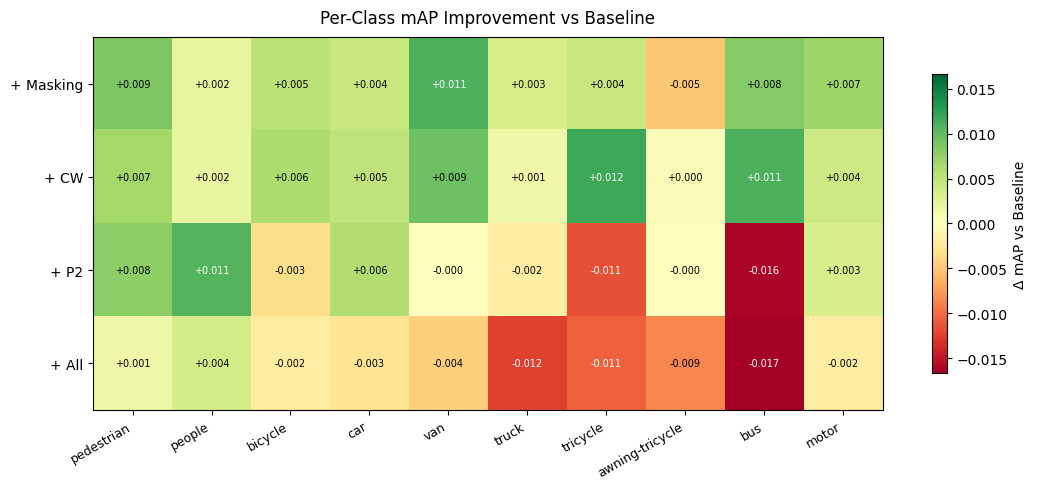

In [40]:
per_class_data = {
    "Baseline": baseline_results["validation_results"].box.maps,
    "+ Masking": masking_results["validation_results"].box.maps,
    "+ CW": class_weighting_results["validation_results"].box.maps,
    "+ P2": p2_results["validation_results"].box.maps,
    "+ All": all_results["validation_results"].box.maps,
}

per_class_df = pd.DataFrame(per_class_data, index = class_names)

variants = ["+ Masking", "+ CW", "+ P2", "+ All"]
for v in variants:
    per_class_df[f"{v} Δ"] = per_class_df[v] - per_class_df["Baseline"]

print("=" * 78)
print("PER-CLASS mAP@0.5:0.95  —  the explainability source for every variant claim")
print("=" * 78)
print(per_class_df.round(4).to_string())

total_train_instances = sum(class_counts)
class_freq = {class_names[i]: class_counts[i] / total_train_instances for i in range(len(class_names))}
sorted_freq = sorted(class_freq.items(), key = lambda x: x[1])
rare_classes   = [c for c, _ in sorted_freq[:3]]
common_classes = [c for c, _ in sorted_freq[-3:]]

print("\nClass frequencies in training data:")
for c in class_names:
    print(f"  {c:<22s}  {class_freq[c]*100:>6.2f}%")

print("\n" + "=" * 78)
print("AUTOMATED JUSTIFICATION READOUT")
print("=" * 78)

for v in variants:
    delta_col = f"{v} Δ"
    overall_delta = per_class_df[delta_col].mean()
    rare_delta = per_class_df.loc[rare_classes,   delta_col].mean()
    common_delta = per_class_df.loc[common_classes, delta_col].mean()
    biggest_winner = per_class_df[delta_col].idxmax()
    biggest_loser = per_class_df[delta_col].idxmin()
    consistency = per_class_df[delta_col].std()

    print(f"\n[{v}]")
    print(f"Mean Δ across classes: {overall_delta:+.4f}")
    print(f" Δ on rare classes: {rare_delta:+.4f}  (avg of {rare_classes})")
    print(f" Δ on common classes: {common_delta:+.4f}  (avg of {common_classes})")
    print(f" Best gain: {biggest_winner} ({per_class_df.loc[biggest_winner, delta_col]:+.4f})")
    print(f" Worst regression: {biggest_loser} ({per_class_df.loc[biggest_loser, delta_col]:+.4f})")
    print(f" Std of per-class deltas: {consistency:.4f}")

    if v == "+ Masking":
        if consistency < 0.01:
            print("Interpretation: low std means improvement is uniform across classes.")
            print("This is the regularization signature — masking helps the model generalize")
            print("rather than helping any specific class. JUSTIFIES the regularization claim.")
        else:
            print("Interpretation: high per-class variance means masking helped some classes")
            print("more than others — closer to a feature-learning effect than pure regularization.")
    elif v == "+ CW":
        rare_minus_common = rare_delta - common_delta
        if rare_minus_common > 0.005:
            print(f"  Interpretation: rare classes gained {rare_minus_common:+.4f} more than common ones.")
            print("This is exactly what class weighting is supposed to do.")
            print("JUSTIFIES the imbalance-targeting intervention.")
        elif rare_minus_common > 0:
            print(f"Interpretation: rare classes gained slightly more ({rare_minus_common:+.4f}) but the")
            print("effect is weak. CW intervention had limited differential impact.")
        else:
            print(f"Interpretation: rare classes did NOT gain more than common ({rare_minus_common:+.4f}).")
            print("CW didn't deliver its intended effect — class_weighting_power may need tuning.")
    elif v == "+ P2":
        if overall_delta > 0:
            print("Interpretation: P2 added a stride-4 detection head specifically for small objects.")
            print(f"Best-gain class '{biggest_winner}' likely contains many small instances in VisDrone.")
            print("Cross-reference with image inspection to confirm small-object correlation.")
            print("JUSTIFIES the architectural addition if best-gain classes are small-object dominant.")
        else:
            print("Interpretation: P2 did not help overall. Possible causes: 20-epoch fine-tune was too")
            print("short for new layers to converge, or P2 layers received insufficient gradient signal.")
    elif v == "+ All":
        independent_sum = sum(per_class_df[f"{x} Δ"].mean() for x in ["+ Masking", "+ CW", "+ P2"])
        print(f"Sum of independent gains: {independent_sum:+.4f}")
        print(f"Actual combined gain: {overall_delta:+.4f}")
        if overall_delta > independent_sum + 0.005:
            print("Interpretation: combined gain exceeds sum of parts — improvements are synergistic.")
        elif overall_delta < independent_sum - 0.005:
            print("Interpretation: combined gain is less than sum of parts — improvements interfere.")
            print("Likely cause: P2's added capacity competes with masking's regularization budget.")
        else:
            print("Interpretation: gains stack roughly additively — each improvement contributes")
            print("independently without major interaction.")

fig, ax = plt.subplots(figsize = (11, 5))
delta_matrix = per_class_df[[f"{v} Δ" for v in variants]].values
v_max = max(abs(delta_matrix.min()), abs(delta_matrix.max()), 0.01)
im = ax.imshow(delta_matrix.T, cmap = "RdYlGn", aspect = "auto", vmin = -v_max, vmax = v_max)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation = 30, ha = "right", fontsize = 9)
ax.set_yticks(range(len(variants)))
ax.set_yticklabels(variants, fontsize = 10)
plt.colorbar(im, ax = ax, label = "Δ mAP vs Baseline", shrink = 0.8)
for i in range(len(variants)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{delta_matrix[j, i]:+.3f}", ha = "center", va = "center", fontsize = 7,
                color = "black" if abs(delta_matrix[j, i]) < v_max * 0.6 else "white")
ax.set_title("Per-Class mAP Improvement vs Baseline", fontsize = 12, pad = 10)
plt.tight_layout()
plt.show()

## 32. Bar Plot Comparison

/tmp/ipykernel_23/381449003.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels, fontsize = 7, rotation = 30, ha = "right")
/tmp/ipykernel_23/381449003.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels, fontsize = 7, rotation = 30, ha = "right")
/tmp/ipykernel_23/381449003.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels, fontsize = 7, rotation = 30, ha = "right")
/tmp/ipykernel_23/381449003.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels, fontsize = 7, rotation = 30, ha = "right")
/tmp/ipykernel_23/381449003.py:26: U

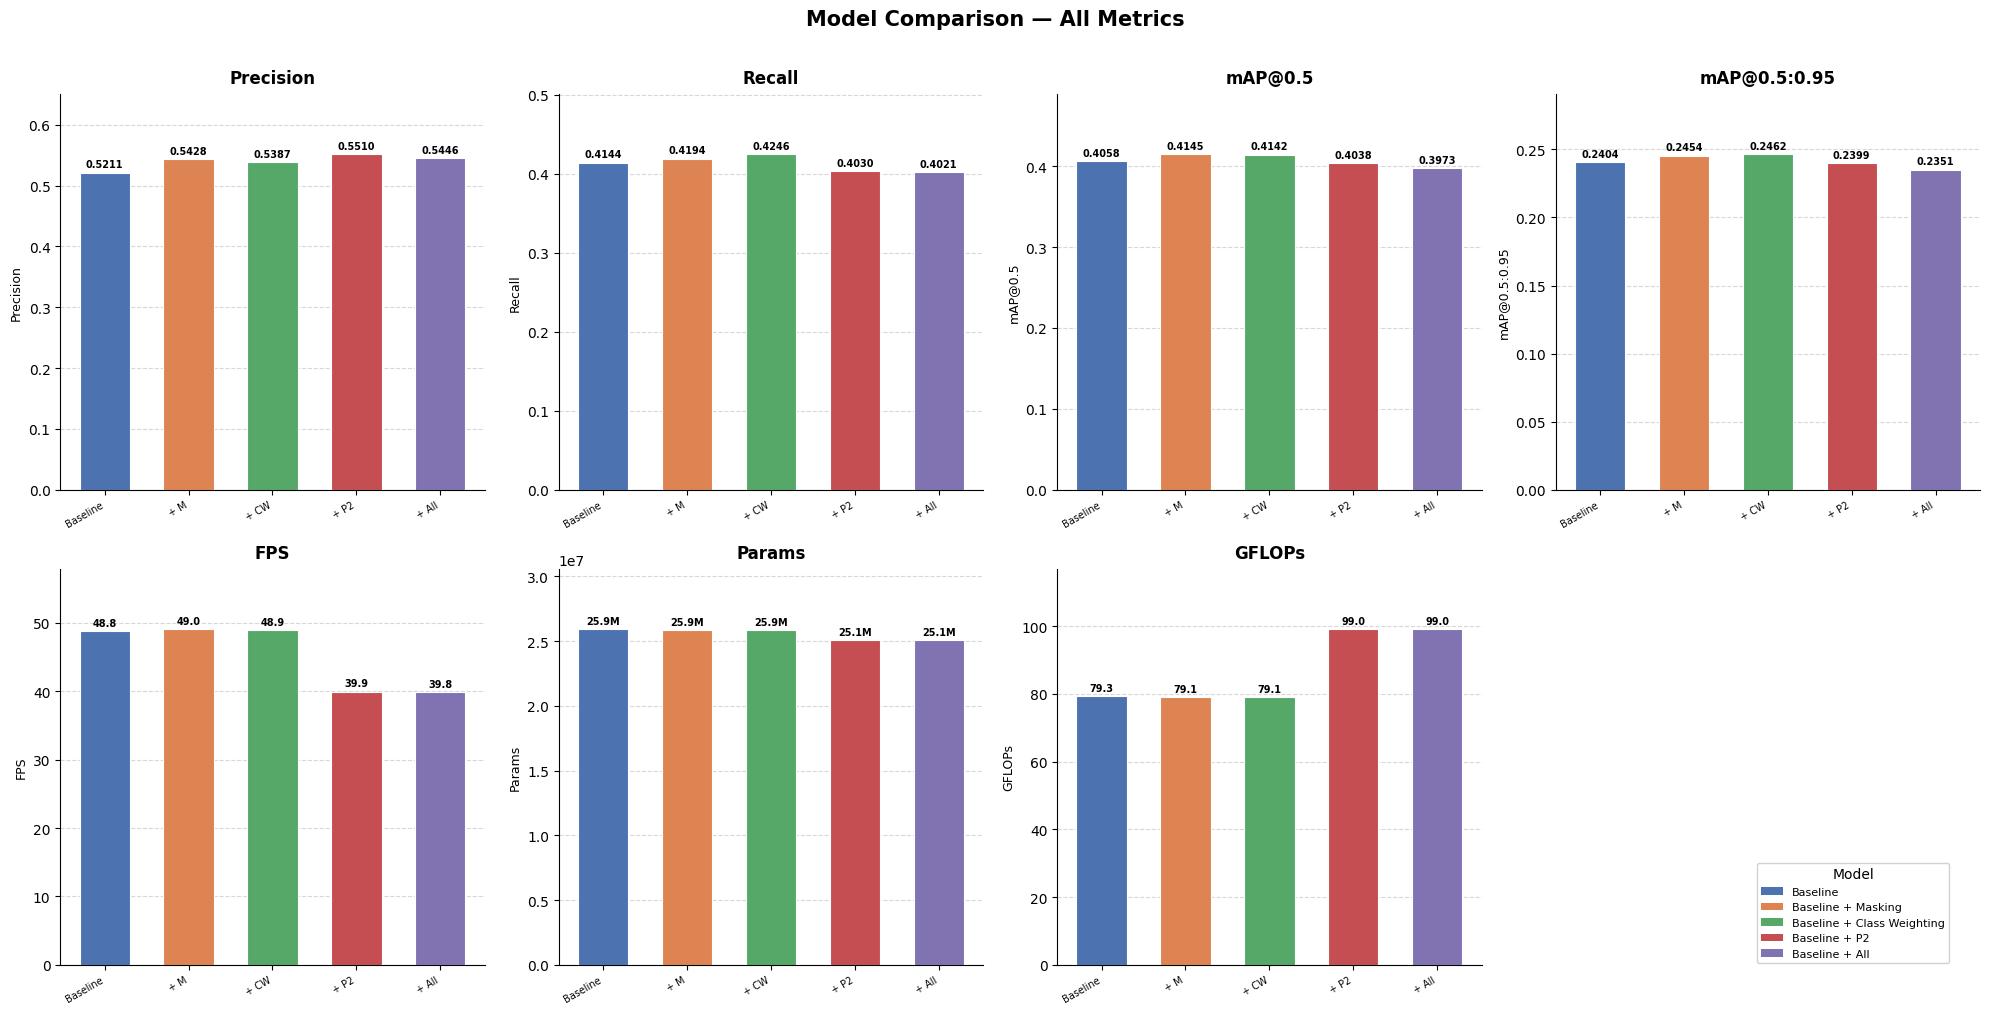

In [ ]:
metrics = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95", "FPS", "Params", "GFLOPs"]
model_labels = summary_table["Model"].tolist()
short_labels = ["Baseline", "+ M", "+ CW", "+ P2", "+ All"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 4, figsize = (20, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = summary_table[metric].tolist()
    plot_values = [0 if (isinstance(v, float) and np.isnan(v)) else v for v in values]
    bars = ax.bar(short_labels, plot_values, color = colors, edgecolor = "white", linewidth = 0.8, width = 0.6)
    for bar, val in zip(bars, values):
        if isinstance(val, float) and np.isnan(val):
            label = "n/a"
        elif metric == "Params":
            label = f"{val / 1e6:.1f}M"
        elif metric in ("FPS", "GFLOPs"):
            label = f"{val:.1f}"
        else:
            label = f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(plot_values) * 0.01,
                label, ha = "center", va = "bottom", fontsize = 7, fontweight = "bold")
    ax.set_title(metric, fontsize = 12, fontweight = "bold", pad = 8)
    ax.set_xticklabels(short_labels, fontsize = 7, rotation = 30, ha = "right")
    ax.set_ylabel(metric, fontsize = 9)
    ax.set_ylim(0, max(plot_values) * 1.18 if max(plot_values) > 0 else 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle = "--", alpha = 0.5)
    ax.set_axisbelow(True)

axes[-1].set_visible(False)

legend_handles = [Patch(facecolor = colors[k], label = model_labels[k]) for k in range(len(model_labels))]
fig.legend(handles = legend_handles, loc = "lower right", fontsize = 8, framealpha = 0.9, title = "Model", title_fontsize = 10, bbox_to_anchor = (0.98, 0.05))

fig.suptitle("Model Comparison — All Metrics", fontsize = 15, fontweight = "bold", y = 1.01)
plt.tight_layout()
plt.show()